# Implementing Reinforcement Learning: https://www.geeksforgeeks.org/machine-learning/what-is-reinforcement-learning/

### This code teaches a robot to find its way through a maze — not by programming the solution manually, but by letting it try and fail thousands of times and learn from the results. That's Reinforcement Learning (RL).

<b> Step 1: Imports </b> </br>
The maze is represented as a 2D NumPy array.
Zero values are safe paths; ones are obstacles the agent must avoid.
Start and goal define the positions where the agent begins and where it aims to reach.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
maze = np.array([
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 1, 1, 0, 1, 0, 1, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 1],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 0, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 1, 1, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 0, 0, 1, 1],
    [1, 0, 1, 0, 1, 0, 1, 0, 0, 1],
    [1, 1, 1, 0, 1, 1, 1, 1, 0, 0]
])

start = (0,0)
goal= (9,9)

<b> Step 2: Parameters </b> </br>
num_episodes: Number of times the agent will attempt to navigate the maze.
</br>alpha: Learning rate that controls how much new information overrides old information.
</br>gamma: Discount factor giving more weight to immediate rewards.
</br>epsilon: Probability of exploration vs exploitation; starts higher to explore more.
</br>Rewards are set to penalize hitting obstacles, reward reaching the goal and slightly penalize each step to find shortest paths.
</br>actions define possible moves: left, right, up, down.
</br>Q is the Q-Table initialized to zero; it stores expected rewards for each state-action pair.

In [10]:
num_episodes = 5000
alpha = 0.1
gamma = 0.9
epsilon = 0.5

reward_fire = -10
reward_goal = 50
reward_step = -1

actions = [(0, -1), (0, 1), (-1, 0), (1, 0)]

Q = np.zeros(maze.shape + (len(actions),))

<b> Step 3: Helpers </b> </br>
<b> is_valid: </b> ensures the agent can only move inside the maze and avoids obstacles. </br>
<b> choose_action:</b> implements exploration (random action) vs exploitation (best learned action) strategy.

In [12]:
def is_valid(pos): # This function will evaluate whether the position is valid or not. It takes a position (row, column) and return true/ false
    r, c = pos # row, column
    if r < 0 or r >= maze.shape[0]:
        return False
    if c < 0 or c >= maze.shape[1]:
        return False
    if maze[r, c] == 1:
        return False
    return True


def choose_action(state): # decide whether explore or exploit 
    if np.random.random() < epsilon: # if the random num is less than 0.5 it will explore
        return np.random.randint(len(actions)) # take a random number between 0 to 3 (4 action)
    else:
        return np.argmax(Q[state]) # take the highest value from the Q table

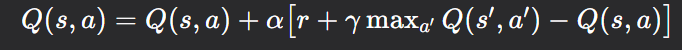

<b> Step 4: Training </b> </br>
s: current state (agent’s position in the maze)
a: action taken at state s (e.g., move left, right, up, down)
r: reward received after taking action a
s′: next state after performing action a
α(alpha): learning rate controlling how much new information overrides old
γ(gamma) discount factor for future rewards

This equation updates the Q-value based on the current reward and the best future Q-value possible from the next state.

In [15]:
rewards_all_episodes = []

for episode in range(num_episodes):
    state = start # start each episode from the beginning (0,0)
    total_rewards = 0
    done = False # if done is True, then it reaches the goal. Otherwise the joruney continues

    while not done: # during the visit
        action_index = choose_action(state) # call the function and returns an action value
        action = actions[action_index] # store the action value which taken from function

        next_state = (state[0] + action[0], state[1] + action[1]) 
        '''State is a tuple (row, column); state[0] = row, state[1]= Column
        action is also a tuple (coordinate); action[0] = change in row
        new_row = current_row + row_change ; new_col = current_col + col_change'''


        if not is_valid(next_state):  #If the next position is a wall or out of bounds: penalize -10 and end the episode. Lesson: 'that direction is bad.'
            reward = reward_fire  
            done = True
        elif next_state == goal: #If the robot reached the goal: reward +50 and end the episode. The best outcome!
            reward = reward_goal
            done = True
        else:  # Otherwise it's a normal valid step. Small -1 penalty to keep the robot looking for a shorter path.
            reward = reward_step

        old_value = Q[state][action_index]
        next_max = np.max(Q[next_state]) if is_valid(next_state) else 0

        Q[state][action_index] = old_value + alpha * \
            (reward + gamma * next_max - old_value)  # Bellman eq: how the function is updating

        state = next_state # shifting the robot into the next state and start from there
        total_rewards += reward

    global epsilon
    epsilon = max(0.01, epsilon * 0.995)
    rewards_all_episodes.append(total_rewards) #After each episode, shrink epsilon by 0.5%. Robot explores less over time. Floor is 0.01 — always keep 1% exploration.

<b> Step 5: Optimized path </b> </br>
This function follows the highest Q-values at each state to extract the best path.
It stops when the goal is reached or no valid next moves are available.
The visited set prevents cycles.

In [17]:
def get_optimal_path(Q, start, goal, actions, maze, max_steps=200): #After training is done, this function traces the best path the robot learned — by always picking the highest Q-value action.
    path = [start]
    state = start
    visited = set()

    for _ in range(max_steps): # max_steps= 200 steps. If the robot hasn't reached the goal by then, something went wrong with training.
        if state == goal:
            break
        visited.add(state)

        best_action = None
        best_value = -float('inf')

        for idx, move in enumerate(actions):
            next_state = (state[0] + move[0], state[1] + move[1])

            if (0 <= next_state[0] < maze.shape[0] and
                0 <= next_state[1] < maze.shape[1] and
                maze[next_state] == 0 and
                    next_state not in visited):

                if Q[state][idx] > best_value:
                    best_value = Q[state][idx]
                    best_action = idx

        if best_action is None:
            break

        move = actions[best_action]
        state = (state[0] + move[0], state[1] + move[1])
        path.append(state)

    return path


optimal_path = get_optimal_path(Q, start, goal, actions, maze)

<b> Step 6: Visualize </b> </br>
The maze and path are visualized using a calming green color palette.
The start and goal positions are visually highlighted.
The learned path is drawn clearly to demonstrate the agent's solution.

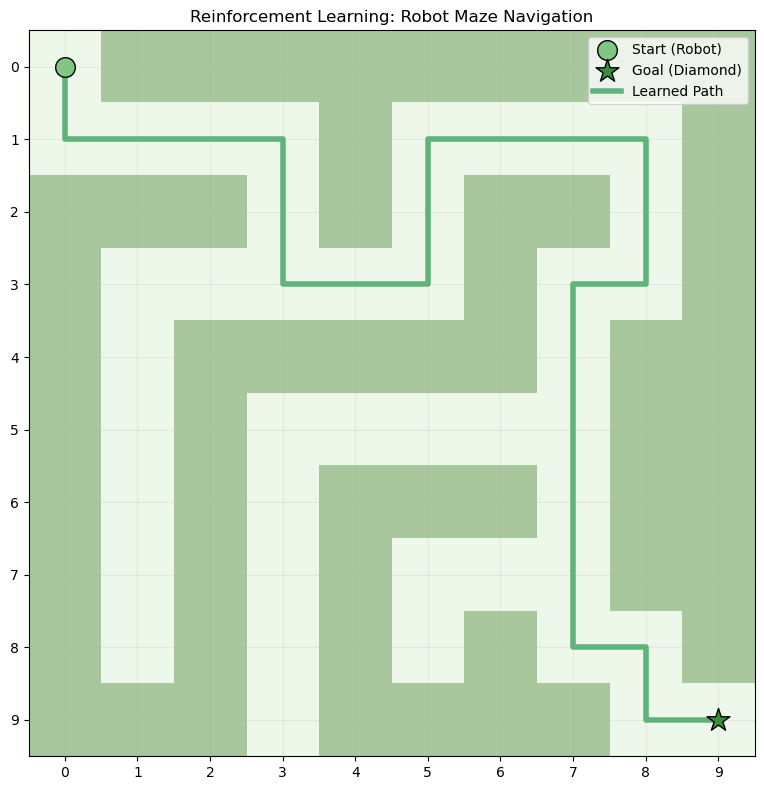

In [35]:
def plot_maze_with_path(path):
    cmap = ListedColormap(['#eef8ea', '#a8c79c'])

    plt.figure(figsize=(8, 8))
    plt.imshow(maze, cmap=cmap)

    plt.scatter(start[1], start[0], marker='o', color='#81c784', edgecolors='black',
                s=200, label='Start (Robot)', zorder=5)
    plt.scatter(goal[1], goal[0], marker='*', color='#388e3c', edgecolors='black',
                s=300, label='Goal (Diamond)', zorder=5)

    rows, cols = zip(*path)
    plt.plot(cols, rows, color='#60b37a', linewidth=4,
             label='Learned Path', zorder=4)

    plt.title('Reinforcement Learning: Robot Maze Navigation')
    #plt.gca().invert_yaxis()
    plt.xticks(range(maze.shape[1]))
    plt.yticks(range(maze.shape[0]))
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_maze_with_path(optimal_path)

Plot Rewards per Training
This plot shows how the agent's overall performance improves across training episodes.
We can observe the total reward trend increasing as the agent learns over time.

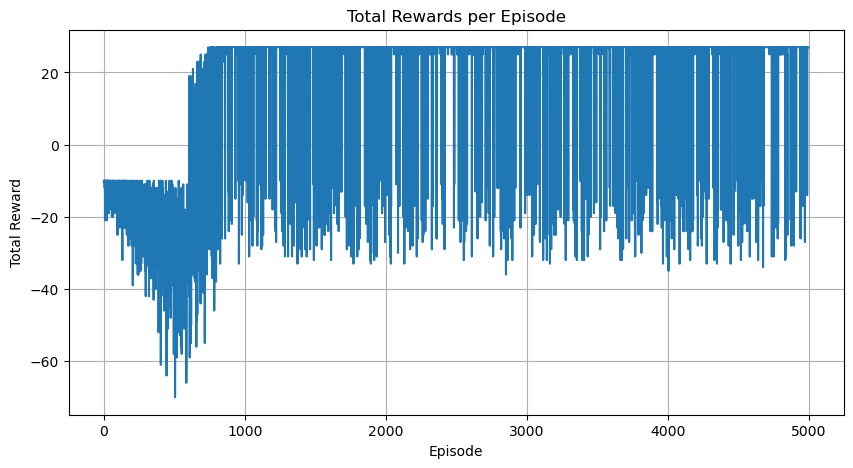

In [39]:
def plot_rewards(rewards):
    plt.figure(figsize=(10, 5))
    plt.plot(rewards)
    plt.title('Total Rewards per Episode')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.grid(True)
    plt.show()


plot_rewards(rewards_all_episodes)